In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Connect to SQL Database

I've now added in the new tables containig the user's playlists and tracks.

In [2]:
# Connect to SQLite database
conn = sqlite3.connect("spotify_dataset.db")
cursor = conn.cursor()

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch and print table names
tables = cursor.fetchall()
print("Tables in database:", tables)

Tables in database: [('spotify_tracks',), ('user_playlists',), ('user_tracks',)]


In [3]:
# Load dataset from SQLite
with sqlite3.connect("spotify_dataset.db") as conn:
    df_spotify_tracks = pd.read_sql_query("SELECT * FROM spotify_tracks;", conn)
    df_user_playlists = pd.read_sql_query("SELECT * FROM user_playlists;", conn)
    df_user_tracks = pd.read_sql_query("SELECT * FROM user_tracks;", conn)

In [4]:
"""Use left join in SQL to combine user_tracks and user_playlists."""

cmd = """SELECT P.id, P.name, P.owner_id, P.owner_display_name, T.playlist_id, T.track_id, T.track_explicit, T.track_album_id, T.track_artists, T.track_duration_ms, T.track_href, T.track_name, T.track_popularity
FROM user_tracks T 
LEFT JOIN user_playlists P 
ON T.playlist_id = P.id"""

with sqlite3.connect("spotify_dataset.db") as conn:
    df_users_PandT = pd.read_sql_query(cmd, conn)
df_users_PandT.head()

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0


In [5]:
df_spotify_tracks.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df_user_playlists.head()

,id,href,description,name,owner_id,owner_display_name,tracks_href,username
0,6csfOWUiqHqZCbKi7oiqu9,https://api.spotify.com/v1/playlists/6csfOWUiq...,Playlist of similar songs based on August 10 b...,August 10,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/6csfOWUiq...,Ava.jts
1,1rHNyjILyZMYPqtUBrK6aa,https://api.spotify.com/v1/playlists/1rHNyjILy...,,Another Indie Playlist,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1rHNyjILy...,Ava.jts
2,4VrgDdNjljYe5f9ftLooXd,https://api.spotify.com/v1/playlists/4VrgDdNjl...,Playlist of similar songs based on Inside Out ...,Sad Sad Sad,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/4VrgDdNjl...,Ava.jts
3,1yI15ngEZ2Yb5OKY409sQ3,https://api.spotify.com/v1/playlists/1yI15ngEZ...,This playlist was created by https:&#x2F;&#x2F...,Need a beat and some sad lyrics,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1yI15ngEZ...,Ava.jts
4,0qANIO5qxX93MV2ZfAS30h,https://api.spotify.com/v1/playlists/0qANIO5qx...,Please add the top five songs from your 2024 S...,W25 NSDC Team Playlist!,315qy5gce4c4gy2gl4u27w2ru5wm,Izzy,https://api.spotify.com/v1/playlists/0qANIO5qx...,Ava.jts


In [7]:
df_user_tracks.head()

,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity,username
0,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0,Ava.jts
1,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0,Ava.jts
2,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0,Ava.jts
3,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0,Ava.jts
4,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0,Ava.jts


I checked to see if there are any duplicate rows in each df, if so I removed them and reset the df indexing.

In [8]:
from music_rec import remove_duplicates
#I turned it into a function

In [9]:
df_spotify_tracks = remove_duplicates(df_spotify_tracks, ['track_name', 'artists'])

There are 32656 duplicate rows based on track_name and artists. Dropping them now...
After dropping duplicates, there are 81344 rows left.


In [10]:
df_user_playlists = remove_duplicates(df_user_playlists, ['name', 'description'])

There are 0 duplicate rows based on name and description.


In [11]:
df_user_tracks = remove_duplicates(df_user_tracks, ['track_name', 'track_popularity'])

There are 415 duplicate rows based on track_name and track_popularity. Dropping them now...
After dropping duplicates, there are 2224 rows left.


In [12]:
df_users_PandT = remove_duplicates(df_users_PandT, ['track_name', 'track_popularity', 'playlist_id'])

There are 76 duplicate rows based on track_name and track_popularity. Dropping them now...
After dropping duplicates, there are 2563 rows left.


Next I created a new df which contains all the user's songs that our kaggle dataset already has, so we can use those song metrics.

In [13]:
#I turned this into a function too, and it includes remove_duplicates within it
from music_rec import prep_dfs
user_df = prep_dfs(df_spotify_tracks, df_user_tracks)
user_df

0


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
0,6LUGvXEAK8WxIBYK43uoTb,The Smiths,Louder Than Bombs,Back to the Old House - 2011 Remaster,74,186626,0,0.626,0.488,2,...,1,0.0253,0.010200,0.000188,0.1410,0.404,104.130,3,punk-rock,27
1,0TZejo18HlJ86OrWNsXKnw,Strawberry Guy,Mrs Magic,Mrs Magic,77,208500,0,0.471,0.634,8,...,1,0.0310,0.159000,0.365000,0.3740,0.366,132.542,4,indie-pop,19
2,3jfZ9M23l0L7RxzYMTgBTv,Joy Again,Looking Out for You,Looking Out for You,80,179499,0,0.682,0.900,9,...,1,0.0874,0.088400,0.063000,0.0685,0.937,100.721,4,garage,15
3,0z1o5L7HJx562xZSATcIpY,Radiohead,OK Computer,Exit Music (For A Film),73,267186,0,0.293,0.276,4,...,0,0.0349,0.224000,0.122000,0.1670,0.195,121.603,4,alt-rock,1
4,14N3tALR3Mhf7UHpJRKk4L,The Front Bottoms,Talon Of The Hawk,Twin Size Mattress,71,264676,0,0.325,0.867,4,...,1,0.0809,0.005480,0.000004,0.1030,0.336,144.866,4,emo,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,5BbAbnlNW3JfGGwG0Hkei9,Otaku;LoFi Waiter,Anime Lofi Vol. 1,Silhouette (Naruto Shippuden),53,113921,0,0.760,0.322,2,...,1,0.0485,0.568000,0.927000,0.0855,0.184,160.028,4,anime,4
202,38gqeaSyRwk64S9Xf1xDzD,Otaku,Anime Lofi Vol. 1,The Hero (One Punch Man),52,101151,0,0.744,0.158,10,...,0,0.0430,0.231000,0.852000,0.1040,0.112,140.190,4,anime,4
203,1ovr8NrhUZWz64ZM1bfbzG,Otaku,Anime Lofi Vol. 2,Sign (Naruto Shippuden),51,117203,0,0.604,0.203,0,...,0,0.0439,0.502000,0.837000,0.1350,0.454,79.998,4,anime,4
204,0hmELN1LsoFyKCE4AqrTFN,Otaku;LoFi Waiter,Ghibli Lofi,The Girl Who Fell from the Sky,58,115216,0,0.635,0.307,0,...,0,0.0446,0.676000,0.904000,0.0928,0.408,150.456,4,anime,4


In [14]:
df_users_PandT.head()

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0


I want to now filter `df_users_PandT` to only contain songs found in `user_df`. Can't use `prep_dfs()` since it outputs df without the playlist name/id column, which we need. Can turn this into function but unsure when we will use this code again.

In [15]:
# Extract column 'track_id' as a list
track_ids = user_df['track_id'].tolist()

# Filter the DataFrame
df_users_PandT = df_users_PandT[df_users_PandT['track_id'].isin(track_ids)]

# Rest the index of rows
df_users_PandT = df_users_PandT.reset_index(drop=True)

df_users_PandT.head()


,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,6LUGvXEAK8WxIBYK43uoTb,0.0,45StnugV9WQMQwk4rRoTy8,"[{""external_urls"": {""spotify"": ""https://open.s...",186626.0,https://api.spotify.com/v1/tracks/6LUGvXEAK8Wx...,Back to the Old House - 2011 Remaster,78.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0TZejo18HlJ86OrWNsXKnw,0.0,3Oovjf1PZOryLQSDKwjJzO,"[{""external_urls"": {""spotify"": ""https://open.s...",208500.0,https://api.spotify.com/v1/tracks/0TZejo18HlJ8...,Mrs Magic,79.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3jfZ9M23l0L7RxzYMTgBTv,0.0,7slouenWhZDdDZibkS4nR3,"[{""external_urls"": {""spotify"": ""https://open.s...",179499.0,https://api.spotify.com/v1/tracks/3jfZ9M23l0L7...,Looking Out for You,77.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0z1o5L7HJx562xZSATcIpY,0.0,6dVIqQ8qmQ5GBnJ9shOYGE,"[{""external_urls"": {""spotify"": ""https://open.s...",267186.0,https://api.spotify.com/v1/tracks/0z1o5L7HJx56...,Exit Music (For A Film),75.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,14N3tALR3Mhf7UHpJRKk4L,0.0,1Xz5zrDqXetBm5HwNGSqPs,"[{""external_urls"": {""spotify"": ""https://open.s...",264676.0,https://api.spotify.com/v1/tracks/14N3tALR3Mhf...,Twin Size Mattress,69.0


# Refine Recommendation System
Want to get a specfied playlist from `df_user_PandT`, then recommend 5 songs based on this specific playlist using our recommender system. This is an existing feature in Spotify, so we want to ensure our recommendation system is just as accurate.

In [16]:
df_users_PandT.head(10)

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,6LUGvXEAK8WxIBYK43uoTb,0.0,45StnugV9WQMQwk4rRoTy8,"[{""external_urls"": {""spotify"": ""https://open.s...",186626.0,https://api.spotify.com/v1/tracks/6LUGvXEAK8Wx...,Back to the Old House - 2011 Remaster,78.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0TZejo18HlJ86OrWNsXKnw,0.0,3Oovjf1PZOryLQSDKwjJzO,"[{""external_urls"": {""spotify"": ""https://open.s...",208500.0,https://api.spotify.com/v1/tracks/0TZejo18HlJ8...,Mrs Magic,79.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3jfZ9M23l0L7RxzYMTgBTv,0.0,7slouenWhZDdDZibkS4nR3,"[{""external_urls"": {""spotify"": ""https://open.s...",179499.0,https://api.spotify.com/v1/tracks/3jfZ9M23l0L7...,Looking Out for You,77.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0z1o5L7HJx562xZSATcIpY,0.0,6dVIqQ8qmQ5GBnJ9shOYGE,"[{""external_urls"": {""spotify"": ""https://open.s...",267186.0,https://api.spotify.com/v1/tracks/0z1o5L7HJx56...,Exit Music (For A Film),75.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,14N3tALR3Mhf7UHpJRKk4L,0.0,1Xz5zrDqXetBm5HwNGSqPs,"[{""external_urls"": {""spotify"": ""https://open.s...",264676.0,https://api.spotify.com/v1/tracks/14N3tALR3Mhf...,Twin Size Mattress,69.0
5,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,2enPRFda84VE2wtI8c86Uf,0.0,6WnfWrfsfu7T9TXbHIFHX9,"[{""external_urls"": {""spotify"": ""https://open.s...",223746.0,https://api.spotify.com/v1/tracks/2enPRFda84VE...,Always Forever,79.0
6,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,1KIJclzEbNhSVw8tiHPWwE,0.0,54lNPJ6xq2QXwG6jLEIf6C,"[{""external_urls"": {""spotify"": ""https://open.s...",189160.0,https://api.spotify.com/v1/tracks/1KIJclzEbNhS...,Young,78.0
7,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,40iocOzytrqaRn5RbGPDNp,0.0,4uNgt1uQs6wZRm4giB3shX,"[{""external_urls"": {""spotify"": ""https://open.s...",208453.0,https://api.spotify.com/v1/tracks/40iocOzytrqa...,Cherry Flavoured,63.0
8,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,2RJfK2pOvGpnxC255YOy5k,0.0,1c9Sx7XdXuMptGyfCB6hHs,"[{""external_urls"": {""spotify"": ""https://open.s...",212853.0,https://api.spotify.com/v1/tracks/2RJfK2pOvGpn...,Rose-Colored Boy,65.0
9,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,0w5Bdu51Ka25Pf3hojsKHh,0.0,1c9Sx7XdXuMptGyfCB6hHs,"[{""external_urls"": {""spotify"": ""https://open.s...",182693.0,https://api.spotify.com/v1/tracks/0w5Bdu51Ka25...,Hard Times,79.0


In [17]:
scaler_test = StandardScaler()
user_df[['track_genre_encoded', 'tempo', 'energy', 'liveness']] = scaler_test.fit_transform(user_df[['track_genre_encoded', 'tempo', 'energy', 'liveness']])

# Create a NearestNeighbors model
knn_model = NearestNeighbors(n_neighbors=5, algorithm='ball_tree') # Adjust n_neighbors (k)
knn_model.fit(user_df[['track_genre_encoded', 'tempo', 'energy', 'liveness']])

NearestNeighbors(algorithm='ball_tree')

In [18]:
def playlist_rec_songs(df, knn, playlist, n=5):

    # Get requested playlist
    df_playlist = df_users_PandT[df_users_PandT['name'].str.lower() == playlist.lower()]

    # Extract column 'track_id' as a list
    playlist_ids = df_playlist['track_id'].tolist()

    # Filter the DataFrame of song metrics to get only the songs with these
    df = df[df['track_id'].isin(playlist_ids)]

    # Rest the index of rows
    df = df.reset_index(drop=True)

    # Ensure `n` does not exceed the number of available songs in the dataset
    max_neighbors = min(n, len(df))  

    # Ensure `user_songs` has enough entries
    num_user_songs = len(df)
    if num_user_songs < max_neighbors:
        print(f"Warning: User provided only {num_user_songs} songs. Adjusting neighbors to {num_user_songs}.")
        max_neighbors = num_user_songs


    # Find nearest neighbors
    distances, indices = knn.kneighbors(df[['track_genre_encoded', 'tempo', 'energy', 'liveness']], n_neighbors=max_neighbors)

    # Get recommended tracks from the spotify dataset
    recommended_tracks = df_spotify_tracks.iloc[indices[0]]

    return recommended_tracks[['artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']]


In [19]:
# Get requested playlist
df_playlist = df_users_PandT[df_users_PandT['name'].str.lower() == 'Another Indie Playlist'.lower()]

df_playlist

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
7,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,40iocOzytrqaRn5RbGPDNp,0.0,4uNgt1uQs6wZRm4giB3shX,"[{""external_urls"": {""spotify"": ""https://open.s...",208453.0,https://api.spotify.com/v1/tracks/40iocOzytrqa...,Cherry Flavoured,63.0
8,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,2RJfK2pOvGpnxC255YOy5k,0.0,1c9Sx7XdXuMptGyfCB6hHs,"[{""external_urls"": {""spotify"": ""https://open.s...",212853.0,https://api.spotify.com/v1/tracks/2RJfK2pOvGpn...,Rose-Colored Boy,65.0
9,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,0w5Bdu51Ka25Pf3hojsKHh,0.0,1c9Sx7XdXuMptGyfCB6hHs,"[{""external_urls"": {""spotify"": ""https://open.s...",182693.0,https://api.spotify.com/v1/tracks/0w5Bdu51Ka25...,Hard Times,79.0
10,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,6lbLn5iL2NBJnbib7bTXMn,0.0,3Ahz3KpKarLfZAb2bYEe65,"[{""external_urls"": {""spotify"": ""https://open.s...",234606.0,https://api.spotify.com/v1/tracks/6lbLn5iL2NBJ...,Dræm Girl,4.0


In [20]:
# Get requested playlist
df_playlist = df_users_PandT[df_users_PandT['name'].str.lower() == 'Another Indie Playlist'.lower()]

# Extract column 'track_id' as a list
playlist_ids = df_playlist['track_id'].tolist()

# Filter the DataFrame of song metrics to get only the songs with these
user_df_playlist = user_df[user_df['track_id'].isin(playlist_ids)]

# Rest the index of rows
user_df_playlist = user_df_playlist.reset_index(drop=True)

user_df_playlist

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
0,40iocOzytrqaRn5RbGPDNp,The Neighbourhood,Chip Chrome & The Mono-Tones,Cherry Flavoured,68,208453,0,0.617,0.258557,6,...,1,0.0276,0.23000,0.010500,-0.550145,0.396,-0.899877,4,alt-rock,-1.459993
1,2RJfK2pOvGpnxC255YOy5k,Paramore,After Laughter,Rose-Colored Boy,66,212853,0,0.768,1.331106,5,...,1,0.0335,0.00199,0.000374,-1.185155,0.926,-0.108217,4,emo,-0.015196
2,0w5Bdu51Ka25Pf3hojsKHh,Paramore,After Laughter,Hard Times,75,182693,0,0.695,1.297057,5,...,0,0.0334,0.00647,0.000005,-1.271018,0.916,0.061102,4,emo,-0.015196
3,6lbLn5iL2NBJnbib7bTXMn,No Vacation,Summer Break Mixtape,Dræm Girl,61,234606,0,0.192,1.867380,2,...,1,0.2580,0.00164,0.716000,1.419046,0.262,1.860194,4,garage,0.225603


In [21]:
df_five_songs = playlist_rec_songs(user_df, knn_model, 'Another Indie Playlist')
df_five_songs.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
7,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,0,0.703,0.444,11,-9.331,1,0.0417,0.559,0.000000,0.0973,0.712,150.960,4,acoustic
92,Ray LaMontagne;Sierra Ferrell,I Was Born To Love You,I Was Born To Love You,67,265843,0,0.650,0.271,9,-11.081,1,0.0314,0.794,0.000069,0.1960,0.210,78.036,4,acoustic
139,Andrew Foy;Renee Foy,Let Her Go,Let Her Go,38,194013,0,0.549,0.291,2,-13.457,1,0.0388,0.858,0.000846,0.1290,0.376,75.153,4,acoustic
112,JJ Heller,I Dream of You: CALM,Make You Feel My Love,57,171293,0,0.678,0.199,9,-9.785,1,0.0307,0.957,0.000003,0.0968,0.262,72.006,4,acoustic


<Axes: title={'center': 'Song Genre Scatterplot'}, xlabel='liveness', ylabel='energy'>

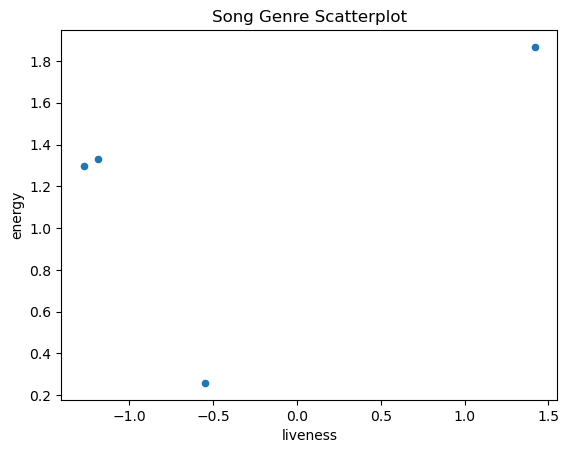

In [22]:
# Filter for the specific genre

# genre_data = user_df[user_df['track_genre'] == 'indie']  


# Create scatter plot with 'runtime' on x-axis and 'rating' on y-axis

user_df_playlist.plot.scatter(x='liveness', y='energy', title='Song Genre Scatterplot') 

<Axes: title={'center': 'Song Genre Scatterplot'}, xlabel='liveness', ylabel='energy'>

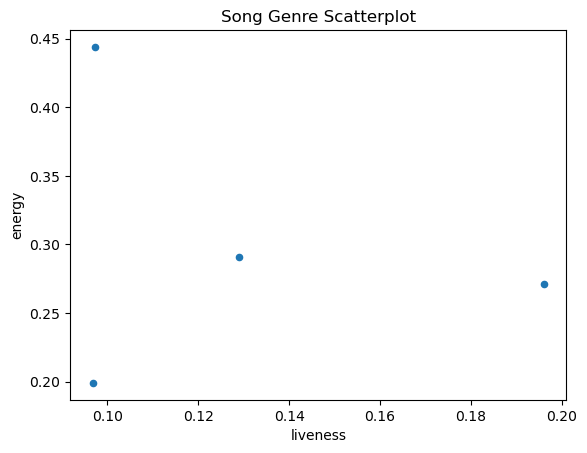

In [23]:
# Filter for the specific genre

# genre_data_recs = df_five_songs[df_five_songs['track_genre'] == 'indie']  


# Create scatter plot with 'runtime' on x-axis and 'rating' on y-axis

df_five_songs.plot.scatter(x='liveness', y='energy', title='Song Genre Scatterplot') 

## Get Playlist Recommendation

In [24]:
# Select relevant numerical features from our user's songs
features = ['danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'loudness']
df_users_filtered = user_df[features]

In [25]:
# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_users_filtered, df_users_filtered, test_size=0.2, random_state=42)

Want to fine tune the KNN model to ensure we are choosing the best parameters.

In [26]:
def tune_knn(X_train, X_test, k_values=range(1, 101)):
    """ Function to find the best k value for KNN model
    """
    best_k = None
    best_score = float('inf')  # Lower score is better
    scores = []

    for k in k_values:
        knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
        knn.fit(X_train)
        
        # Find distances to test points
        distances, _ = knn.kneighbors(X_test, n_neighbors=k)
        
        # Compute Mean Squared Error (MSE)
        mse = np.mean(distances**2)
        scores.append((k, mse))
        
        # Track best k
        if mse < best_score:
            best_score = mse
            best_k = k
    
    return best_k, scores

In [27]:
# Find the best k value
best_k, scores = tune_knn(X_train, X_test)
print(f"Optimal number of neighbors: {best_k}")

Optimal number of neighbors: 1


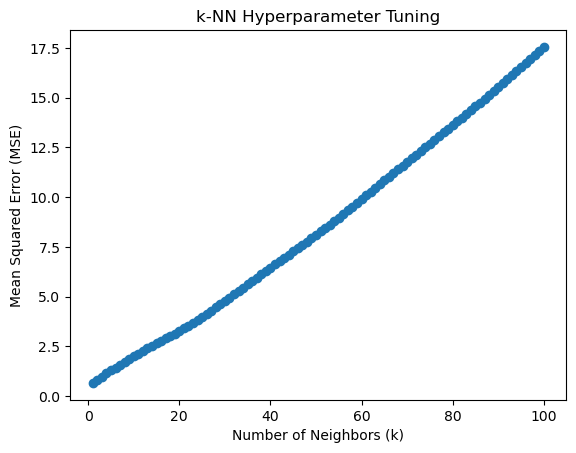

In [28]:
# Plot results
import matplotlib.pyplot as plt

k_values, mse_scores = zip(*scores)
plt.plot(k_values, mse_scores, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("k-NN Hyperparameter Tuning")
plt.show()

There are possible signs of overfitting since the best n_neighbor is 1, and the MSE scores are so accurate.

In [29]:
# Fit k-NN model with 7 features
knn = NearestNeighbors(n_neighbors=best_k, metric='euclidean')
knn.fit(df_users_filtered[features])

NearestNeighbors(metric='euclidean', n_neighbors=1)

We can now create a playlist based on the user's overall tracks. 

In [30]:
def recommend_songs(user_songs, genre=None, n=30):
    """ Function to recommend songs based on playlist
    Args: 
        user_songs: db full of playlists (rows must be >= n)
        genre: string, optional, genre provided by user to group tracks
        n: number of songs being recommended

    Returns:
        recommended_tracks: db which contains the n many recommended songs
    """
    
    # Filter dataset by genre if specified
    if genre:
        df_spot_filtered = df_spotify_tracks[df_spotify_tracks['track_genre'].str.lower() == genre.lower()]
        if df_spot_filtered.empty:
            print(f"Warning: No songs found for genre '{genre}'. Using all genres instead.")
            df_spot_filtered = df_spotify_tracks  # Fall back to all songs
    else:
        df_spot_filtered = df_spotify_tracks  # Use all genres if none specified

    # Ensure `n` does not exceed the number of available songs in the dataset
    max_neighbors = min(n, len(df_spot_filtered))  

    # Ensure `user_songs` has enough entries
    num_user_songs = len(user_songs)
    if num_user_songs < max_neighbors:
        print(f"Warning: User provided only {num_user_songs} songs. Adjusting neighbors to {num_user_songs}.")
        max_neighbors = num_user_songs

    # Create and scale the users songs with the given features
    scaler = StandardScaler()
    user_songs_scaled = scaler.fit_transform(user_songs[features])

     # Fit a k-NN model specifically for the filtered dataset
    knn_filtered = NearestNeighbors(n_neighbors=max_neighbors, metric='euclidean')
    knn_filtered.fit(df_spot_filtered[features])

    # Find nearest neighbors
    distances, indices = knn_filtered.kneighbors(user_songs_scaled, n_neighbors=max_neighbors)

    # Get recommended tracks from the filtered dataset
    recommended_tracks = df_spot_filtered.iloc[indices[0]]

    return recommended_tracks[['track_name', 'artists', 'track_genre', 'loudness', 'danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence']]


In [31]:

recommendations = recommend_songs(df_users_filtered, genre='indie')
recommendations

c:\Users\avajt\anaconda3\envs\PIC16B-25W\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,track_name,artists,track_genre,loudness,danceability,energy,tempo,speechiness,acousticness,instrumentalness,valence
44963,Could I Love You Any More (feat. Jason Mraz),Reneé Dominique;Jason Mraz,indie,-8.001,0.288,0.371,52.572,0.0386,0.66600,0.000000,0.197
44930,Mellow,Rohit Shakya;Sajjan Raj Vaidya,indie,-4.912,0.695,0.780,74.978,0.0514,0.11000,0.000143,0.604
44903,Maya,Chowraasta,indie,-5.612,0.585,0.325,75.032,0.0972,0.27900,0.000000,0.250
44955,Ghuroor,Izzchughtai;Abdul Hannan,indie,-13.000,0.392,0.331,74.824,0.1280,0.73700,0.000002,0.260
44865,I Love You So,The Walters,indie,-4.891,0.575,0.648,75.977,0.0358,0.58300,0.000000,0.466
44943,Somos Instantes,Caloncho,indie,-13.572,0.797,0.403,74.997,0.1050,0.77600,0.340000,0.664
44935,I Hear a Symphony,Cody Fry,indie,-8.542,0.197,0.247,75.787,0.0306,0.93400,0.016300,0.407
44864,Ra Ra Reddy I Am Ready,Lipsika;Aditya Iyengar,indie,-7.528,0.738,0.903,78.971,0.2530,0.38300,0.010900,0.699
44901,Young,Vacations,indie,-4.065,0.498,0.810,79.935,0.0263,0.00392,0.007170,0.594
44917,Rangarattinam,Tenma;M.S Krsna;Gana Muthu;Sangita Santhosham;...,indie,-6.439,0.738,0.758,82.482,0.1300,0.27300,0.000072,0.840


In [32]:
from music_rec import recommend_songs
recommend_songs(df_users_filtered, df_spotify_tracks, genre = 'pop')

c:\Users\avajt\anaconda3\envs\PIC16B-25W\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,track_name,artists,track_genre,loudness,danceability,energy,tempo,speechiness,acousticness,instrumentalness,valence
61466,Mujhe Peene Do,Darshan Raval,pop,-8.877,0.268,0.334,55.832,0.0332,0.75900,0.000000,0.1750
61369,"Chogada (From ""Loveyatri"")",Darshan Raval;Asees Kaur;Lijo George-Dj Chetas,pop,-3.452,0.359,0.972,62.914,0.1090,0.13600,0.000003,0.5950
61314,Baby,Justin Bieber;Ludacris,pop,-5.237,0.728,0.859,65.043,0.1370,0.04010,0.000000,0.5350
61470,Baarish Lete Aana,Darshan Raval,pop,-8.937,0.537,0.350,67.018,0.0248,0.83800,0.000000,0.3180
61270,Lover,Taylor Swift,pop,-7.582,0.359,0.543,68.505,0.0915,0.49200,0.000016,0.4530
61494,Happiness is a butterfly,Lana Del Rey,pop,-10.990,0.467,0.119,70.499,0.0401,0.96900,0.000001,0.1560
61399,Maine Royaan (Lofi Remix),Tanveer Evan;Ahmed Shakib,pop,-9.909,0.350,0.468,71.312,0.0385,0.44500,0.034000,0.0467
61393,Arcade,Duncan Laurence,pop,-12.603,0.450,0.329,71.884,0.0441,0.81800,0.001090,0.2660
61493,Ek Tarfa - Reprise,Darshan Raval,pop,-9.537,0.320,0.453,72.424,0.0329,0.88900,0.000003,0.4440
61447,Happier Than Ever,Billie Eilish,pop,-8.802,0.314,0.238,72.535,0.0389,0.74100,0.001930,0.3030


<Axes: title={'center': 'Song Genre Scatterplot'}, xlabel='loudness', ylabel='energy'>

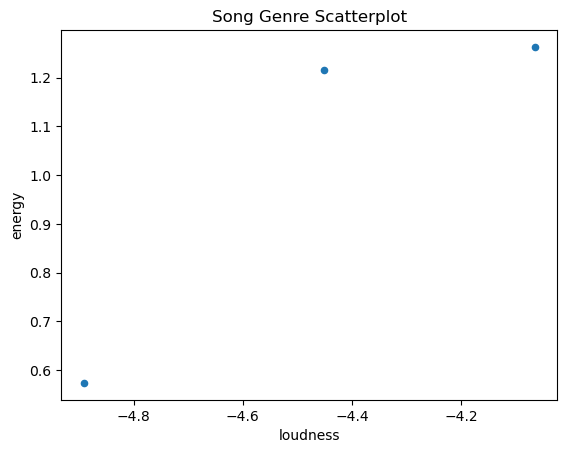

In [33]:
# Filter for the specific genre

genre_data = user_df[user_df['track_genre'] == 'indie']  


# Create scatter plot with 'runtime' on x-axis and 'rating' on y-axis

genre_data.plot.scatter(x='loudness', y='energy', title='Song Genre Scatterplot') 

<Axes: title={'center': 'Song Genre Scatterplot'}, xlabel='loudness', ylabel='energy'>

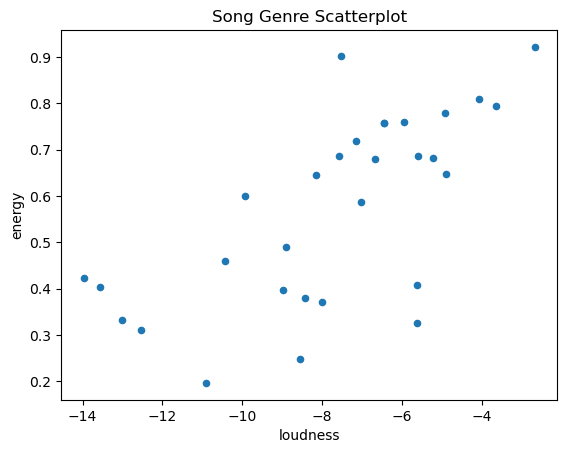

In [34]:
# Filter for the specific genre

genre_data_recs = recommendations[recommendations['track_genre'] == 'indie']  


# Create scatter plot with 'runtime' on x-axis and 'rating' on y-axis

genre_data_recs.plot.scatter(x='loudness', y='energy', title='Song Genre Scatterplot') 

I am going to try and make a better graph visual using plotly, but I think there is a correlation there and I would like to show it! 